# 03. Differential Privacy

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply differential privacy concepts and mechanisms
- Quantify and tune privacy–utility trade-offs
- Use DP in realistic ML settings

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 01 "Probability Distributions for ML" — a DP mechanism works by adding noise drawn from a chosen distribution, so its guarantee is a statement about that distribution.

---


# 03. Differential Privacy

## 🚨 THE PROBLEM: We Need Mathematical Privacy Guarantees

**Remember the limitation from the previous notebook?**

We learned advanced privacy-enhancing technologies like homomorphic encryption and secure multi-party computation. But we discovered:

**How do we provide mathematical privacy guarantees?**

**The Problem**: We need stronger guarantees:
- ❌ **Mathematical privacy guarantees** (not just techniques)
- ❌ **Quantifiable privacy protection** (measurable privacy loss)
- ❌ **Formal privacy definitions** (differential privacy)
- ❌ **Provable privacy bounds** (epsilon-delta guarantees)

**We've learned:**
- ✅ How to use basic data protection (Notebook 1)
- ✅ How to use advanced privacy technologies (Notebook 2)
- ✅ Privacy-utility trade-offs

**But we haven't learned:**
- ❌ How to **quantify privacy** mathematically
- ❌ How to **prove privacy protection** formally
- ❌ How to use **differential privacy** for provable guarantees
- ❌ How to **measure privacy loss** (epsilon parameter)

**We need differential privacy** to:
1. Provide mathematical privacy guarantees
2. Quantify privacy loss (epsilon parameter)
3. Prove privacy protection formally
4. Enable privacy-preserving data analysis with provable guarantees

**This notebook solves that problem** by teaching you differential privacy with mathematical guarantees!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Data Protection** - Understanding basic protection
- ✅ **Example 2: Privacy Technologies** - Understanding PETs
- ✅ **Basic Python knowledge**: Functions, data manipulation
- ✅ **Basic statistics**: Understanding of means, counts, noise

**If you haven't completed these**, you might struggle with:
- Understanding why mathematical guarantees matter
- Knowing how epsilon parameter works
- Understanding privacy-utility trade-offs in differential privacy

---

## 🔗 Where This Notebook Fits

**This is the THIRD example in Unit 3** - it teaches you mathematical privacy guarantees!

**Why this example THIRD?**
- **Before** you can use differential privacy, you need basic protection (Example 1)
- **Before** you can use differential privacy, you need to understand PETs (Example 2)
- **Before** you can ensure GDPR compliance, you need privacy guarantees

**Builds on**: 
- 📓 Example 1: Data Protection (basic protection strategies)
- 📓 Example 2: Privacy Technologies (advanced PETs)

**Leads to**: 
- 📓 Example 4: GDPR Compliance (regulatory compliance)
- 📓 Example 5: Secure Development (secure coding practices)

**Why this order?**
1. Differential privacy provides **mathematical guarantees** (strongest privacy)
2. Differential privacy enables **provable privacy** (critical for compliance)
3. Differential privacy shows **quantifiable protection** (epsilon parameter)

---

## The Story: Provable Privacy

Imagine you're a scientist publishing research results. **Before** differential privacy, you'd say "we anonymized the data" but couldn't prove how private it was. **After** using differential privacy, you can say "we provide (ε=0.5)-differential privacy" - a mathematical guarantee!

Same with AI: **Before** we use privacy techniques but can't prove privacy, now we learn differential privacy - add noise with epsilon parameter to get provable privacy guarantees! **After** differential privacy, we can mathematically prove our systems are private!

---

## Why Differential Privacy Matters

Differential privacy is essential for ethical AI:
- **Mathematical Guarantees**: Provable privacy protection
- **Quantifiable Privacy**: Measure privacy loss (epsilon)
- **Formal Definition**: Rigorous privacy definition
- **Compliance**: Meet strict privacy regulations
- **Trust**: Build confidence with provable guarantees

## Learning Objectives
1. Understand differential privacy and epsilon parameter
2. Learn how to add noise for privacy
3. Understand privacy-utility trade-offs
4. Apply differential privacy to data analysis
5. Compare different epsilon values
6. Understand when to use differential privacy

## 📌 The case: the US Census published tables, and researchers rebuilt the people

The single largest deployment of differential privacy in the world exists because of one
internal experiment.

In a 2023 working paper — *The 2010 Census Confidentiality Protections Failed, Here's How
and Why* — the **US Census Bureau** attacked its own published data. Using only **34
published tables** from Summary File 1, the team reconstructed five variables (census block,
sex, age, race, ethnicity) for the underlying person-level records. Their findings:

- an attacker, **using only published data**, can verify that every record in **70 % of all
  census blocks — 97 million people — was perfectly reconstructed**;
- within those blocks, the actual census responses on **race and ethnicity for 3.4 million
  "population uniques"** (people with unusual characteristics) can be inferred with **95 %
  accuracy** — the same precision as the confidential microdata itself.

The 2010 protections rested on the assumption that **aggregation prevents reconstruction**.
It does not. That is what moved the Bureau to a **differentially private disclosure-avoidance
system for the 2020 Census** — the mechanism you are about to run, at national scale, on the
constitutionally mandated count of a country.

**It is not settled, and that is part of the lesson.** In March 2021 the State of Alabama
sued the Department of Commerce over exactly this decision, arguing the injected noise
damaged the redistricting data the census exists to produce. The court denied the injunction
in June 2021 and Alabama withdrew in September 2021; the argument about how much accuracy a
democracy should trade for confidentiality did not end there.

**The WHY — what goes wrong without differential privacy.** Every other technique in this
unit protects one release and says nothing about the next. Publish enough true aggregates
and an attacker reconstructs the rows, as the Bureau just demonstrated on itself. DP is the
only framework here that (a) makes a **provable** statement about what any attacker can
learn and (b) **accumulates** across releases, so you can say when you have spent your
budget. You are about to publish a real, genuinely sensitive count — how many patients in a
real cohort have a malignant tumour — at four privacy budgets, and measure what each one
costs.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **`sklearn.datasets.load_breast_cancer`** - 569 real tumour biopsies from the
  Wisconsin Diagnostic Breast Cancer study, with real measured features and real
  malignant/benign diagnoses. The count we protect ("how many patients in this
  cohort have a malignant tumour") is a real, genuinely sensitive statistic.

**Outputs:** What you'll see when you run the cells

- A real count published under four different privacy budgets
- The measured error each budget costs, averaged over many releases
- A real diagnostic model trained on Laplace-noised real features at each ε,
  scored against the same model trained with no noise at all

> **The randomness in this notebook is the lesson, not a shortcut.** Differential
> privacy *is* a noise mechanism: `np.random.laplace` here is the algorithm being
> taught, applied to a real dataset. Nothing in the data itself is invented.

---

## Part 1: The Laplace Mechanism

**Differential privacy (DP)** gives a *mathematical* guarantee: the published result would
look almost the same whether or not any single person's record is in the dataset. The
strength of the guarantee is the **privacy budget ε (epsilon)** - smaller ε = stronger privacy.

The workhorse is the **Laplace mechanism**: to publish a query answer, add noise drawn from
a Laplace distribution with scale

```
scale = sensitivity / epsilon
```

where *sensitivity* is how much one person can change the true answer (for a count: 1).

In [1]:
# Why: differential privacy gives a PROVABLE guarantee - the published number
# barely changes whether or not any single person is in the data.

# Step 1: Differentially private counts with the Laplace mechanism

import numpy as np
from sklearn.datasets import load_breast_cancer

np.random.seed(42)

print("="*80)
print("🎲 LAPLACE MECHANISM: PRIVATE COUNTS ON REAL PATIENT DATA")
print("="*80)

# REAL sensitive data: 569 real tumour biopsies from the Wisconsin Diagnostic
# Breast Cancer study. sklearn encodes target 0 = malignant, 1 = benign.
cancer = load_breast_cancer()
has_condition = (cancer.target == 0).astype(int)   # 1 = this real patient's tumour was malignant
n_patients = len(has_condition)
true_count = has_condition.sum()

print(f"\nReal cohort size: {n_patients} patients")
print(f"True count of malignant diagnoses (the SECRET): {true_count}")
print(f"True prevalence: {true_count / n_patients:.1%}")
print("\nA hospital asked to publish this count faces a real problem: an attacker")
print("who knows the count before and after one patient joins learns that patient's")
print("diagnosis exactly. DP is the defence.")

def dp_count(data, epsilon, sensitivity=1.0):
    """Release a count with (epsilon)-differential privacy.

    Sensitivity is 1 because adding or removing one patient changes a count by
    at most 1. The noise scale is sensitivity/epsilon - smaller epsilon means
    more noise and a stronger guarantee.
    """
    noise = np.random.laplace(loc=0.0, scale=sensitivity / epsilon)
    return data.sum() + noise

print("\nOne noisy release per epsilon (rerun -> different noise):")
for eps in [0.1, 0.5, 1.0, 2.0]:
    print(f"  epsilon={eps:<4}: published count = {dp_count(has_condition, eps):8.1f}"
          f"   (true value {true_count})")

# Average error over many releases quantifies the utility cost
print("\nMean absolute error over 1000 simulated releases:")
for eps in [0.1, 0.5, 1.0, 2.0]:
    errors = [abs(dp_count(has_condition, eps) - true_count) for _ in range(1000)]
    mean_err = np.mean(errors)
    print(f"  epsilon={eps:<4}: mean |error| = {mean_err:6.1f}   "
          f"({mean_err / true_count:.1%} of the true count)")
print("\nSmaller epsilon -> stronger privacy -> larger error. That IS the trade-off.")
print("But look at the right-hand column: even the strictest budget here costs")
print("only a few percent of the answer. DP is CHEAP for a count this large.")

# The other half of the story: the same absolute noise is devastating for a
# small subgroup. This is a real, and frequently missed, property of DP.
print("\n" + "-"*80)
print("THE SAME NOISE, A SMALLER GROUP")
print("-"*80)
# A real subgroup: patients whose tumours had the largest mean radius.
large_tumour = cancer.data[:, 0] > np.percentile(cancer.data[:, 0], 95)
subgroup = has_condition[large_tumour]
sub_true = subgroup.sum()
print(f"Real subgroup: the {large_tumour.sum()} patients with the largest tumours "
      f"(top 5% by mean radius)")
print(f"True malignant count in that subgroup: {sub_true}")
print("\nSame mechanism, same epsilons, much smaller true answer:")
for eps in [0.1, 0.5, 1.0, 2.0]:
    errors = [abs(dp_count(subgroup, eps) - sub_true) for _ in range(1000)]
    mean_err = np.mean(errors)
    print(f"  epsilon={eps:<4}: mean |error| = {mean_err:6.1f}   "
          f"({mean_err / max(sub_true, 1):.1%} of the true count)")
print("\nCompare the percentages against the full-cohort table above. The noise")
print("in absolute terms is IDENTICAL - the mechanism does not know or care how")
print("big the group is - but as a share of the answer it is far larger here.")
print("\n💡 THE LESSON: differential privacy is most expensive precisely for small")
print("   groups, which are often minority groups. A privacy budget that looks")
print("   harmless on the aggregate can make a subgroup's statistics unusable -")
print("   linking this notebook straight back to the fairness work in Unit 2.")
print("\nChoosing epsilon is choosing how much of your answer you are willing to")
print("destroy in order to protect the people in it - and that cost is not")
print("distributed equally.")

🎲 LAPLACE MECHANISM: PRIVATE COUNTS ON REAL PATIENT DATA

Real cohort size: 569 patients
True count of malignant diagnoses (the SECRET): 212
True prevalence: 37.3%

A hospital asked to publish this count faces a real problem: an attacker
who knows the count before and after one patient joins learns that patient's
diagnosis exactly. DP is the defence.

One noisy release per epsilon (rerun -> different noise):
  epsilon=0.1 : published count =    209.1   (true value 212)
  epsilon=0.5 : published count =    216.6   (true value 212)
  epsilon=1.0 : published count =    212.6   (true value 212)
  epsilon=2.0 : published count =    212.1   (true value 212)

Mean absolute error over 1000 simulated releases:
  epsilon=0.1 : mean |error| =   10.0   (4.7% of the true count)
  epsilon=0.5 : mean |error| =    2.1   (1.0% of the true count)
  epsilon=1.0 : mean |error| =    1.0   (0.5% of the true count)
  epsilon=2.0 : mean |error| =    0.5   (0.2% of the true count)

Smaller epsilon -> stronger 

## Part 2: The Privacy-Utility Trade-off (including an ML setting)

Every release spends privacy budget. Below we (1) chart the error-vs-ε curve, and
(2) show a *machine-learning* version of the trade-off: training on Laplace-noised
features and measuring test accuracy at each ε.

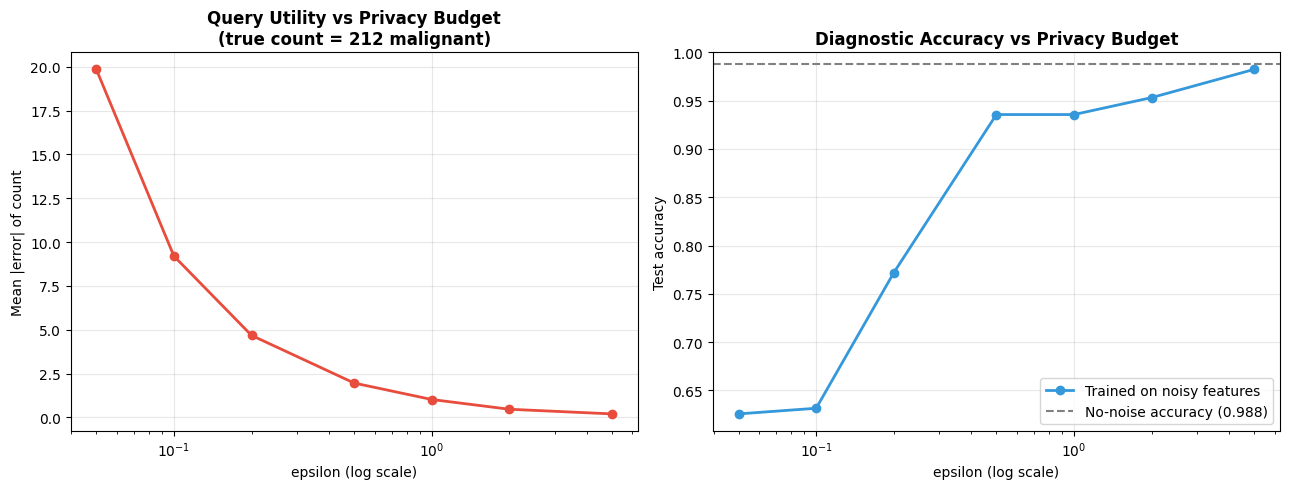

Diagnostic accuracy at each epsilon (real patients, real diagnoses):
  epsilon=0.05 : test accuracy 0.626   (cost vs no-noise: -0.363)
  epsilon=0.1  : test accuracy 0.632   (cost vs no-noise: -0.357)
  epsilon=0.2  : test accuracy 0.772   (cost vs no-noise: -0.216)
  epsilon=0.5  : test accuracy 0.936   (cost vs no-noise: -0.053)
  epsilon=1.0  : test accuracy 0.936   (cost vs no-noise: -0.053)
  epsilon=2.0  : test accuracy 0.953   (cost vs no-noise: -0.035)
  epsilon=5.0  : test accuracy 0.982   (cost vs no-noise: -0.006)
  no noise    : test accuracy 0.988

Across the budgets we swept, accuracy ran from 0.626 to 0.982,
against 0.988 with no privacy protection at all.

Think about what those numbers mean on THIS dataset: it is a cancer
screening task. The accuracy you give up at a strict epsilon is measured in
missed diagnoses. That is the honest shape of the privacy-utility trade-off -
not an abstract curve, but a decision with a cost on both sides.

Note: production DP-ML uses noi

In [2]:
# Why: epsilon is a dial, not a switch - these plots show exactly what each
# notch of privacy costs in query error and in model accuracy.

# Step 2: Visualize the trade-off, then apply DP noise in an ML setting

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Sweep the privacy budget and measure the average error of the private count.
epsilons = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
mae = []
for eps in epsilons:
    errors = [abs(dp_count(has_condition, eps) - true_count) for _ in range(500)]
    mae.append(np.mean(errors))

# ML setting on the SAME real patients: predict malignant vs benign from the
# 30 real measured features, but train on Laplace-noised features
# (input perturbation).
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
# Scale first: these real features range from ~0.05 (smoothness) to ~2500
# (worst area). Without scaling, one unit of Laplace noise would be
# meaningless on one feature and catastrophic on another.
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

np.random.seed(0)
FEATURE_SENSITIVITY = 1.0   # simplification for teaching (post-scaling)
accs = []
for eps in epsilons:
    X_noisy = X_train_s + np.random.laplace(0, FEATURE_SENSITIVITY / eps,
                                            X_train_s.shape)
    model = LogisticRegression(max_iter=1000).fit(X_noisy, y_train)
    accs.append(accuracy_score(y_test, model.predict(X_test_s)))
clean_acc = accuracy_score(
    y_test, LogisticRegression(max_iter=1000).fit(X_train_s, y_train).predict(X_test_s))

# Left: query error vs epsilon. Right: model accuracy vs epsilon (dashed = no noise).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epsilons, mae, 'o-', color='#e74c3c', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('epsilon (log scale)'); axes[0].set_ylabel('Mean |error| of count')
axes[0].set_title(f'Query Utility vs Privacy Budget\n(true count = {true_count} malignant)',
                  fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[1].plot(epsilons, accs, 'o-', color='#3498db', linewidth=2,
             label='Trained on noisy features')
axes[1].axhline(clean_acc, color='gray', linestyle='--',
                label=f'No-noise accuracy ({clean_acc:.3f})')
axes[1].set_xscale('log')
axes[1].set_xlabel('epsilon (log scale)'); axes[1].set_ylabel('Test accuracy')
axes[1].set_title('Diagnostic Accuracy vs Privacy Budget',
                  fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Diagnostic accuracy at each epsilon (real patients, real diagnoses):")
for eps, a in zip(epsilons, accs):
    print(f"  epsilon={eps:<5}: test accuracy {a:.3f}   "
          f"(cost vs no-noise: {a - clean_acc:+.3f})")
print(f"  no noise    : test accuracy {clean_acc:.3f}")

worst = accs[0]; best = accs[-1]
print(f"\nAcross the budgets we swept, accuracy ran from {worst:.3f} to {best:.3f},")
print(f"against {clean_acc:.3f} with no privacy protection at all.")
print("\nThink about what those numbers mean on THIS dataset: it is a cancer")
print("screening task. The accuracy you give up at a strict epsilon is measured in")
print("missed diagnoses. That is the honest shape of the privacy-utility trade-off -")
print("not an abstract curve, but a decision with a cost on both sides.")
print("\nNote: production DP-ML uses noisy GRADIENTS (DP-SGD) with careful budget")
print("accounting; noising features like this is the simplest way to SEE the trade-off.")

## 💬 Discuss

Your own sweep, on 569 real biopsies with real diagnoses:

| ε | Test accuracy | Cost vs no noise |
|---|---|---|
| 0.05 | 0.626 | −0.363 |
| 0.2 | 0.772 | −0.216 |
| 0.5 | 0.936 | −0.053 |
| 1.0 | 0.936 | −0.053 |
| 5.0 | 0.982 | −0.006 |
| no noise | **0.988** | — |

1. **Set ε for a cancer screen and defend it.** At ε = 0.05 the classifier scores 0.626 on a
   malignancy task — barely better than a coin on this cohort — and that is measured in
   missed diagnoses. At ε = 5.0 the accuracy cost is 0.006 and the formal guarantee is so
   weak that many privacy researchers would not call it meaningful protection. Pick a number.
   Then say who you would have to convince: the patients, the hospital's lawyers, or the
   ethics board — and which of the three would find your number hardest to accept.
2. **Whose accuracy, and who notices?** DP noise is added to *everyone's* statistic, but it
   damages **small counts proportionally more**. So a differentially private release
   systematically degrades the numbers describing small groups — rural districts, small
   ethnic populations, rare diagnoses — which are frequently the groups an equity analysis
   most needs. Alabama's complaint was a version of this argument. Is a privacy mechanism
   that hits minorities hardest a fair privacy mechanism? What would you do about it?
3. **Who owns the budget?** ε is cumulative: every query spends some, forever. In a hospital
   with fifty researchers, somebody must refuse the fifty-first query of the year. Should
   that person sit in IT, in research, or in the ethics board — and what happens when the
   query that exhausts the budget is a request to check whether a treatment is killing
   people? Design the escalation rule, then find the case that breaks it.


---

## 🚫 When Differential Privacy Hits a Limitation

### The Limitation We Discovered

We've learned differential privacy with mathematical guarantees. **But there's still a challenge:**

**How do we ensure our AI systems comply with privacy regulations like GDPR?**

Differential privacy works well when:
- ✅ We can add noise to queries
- ✅ We can quantify privacy loss (epsilon)
- ✅ We can prove mathematical privacy guarantees

**But real-world AI systems must also:**
- ❌ **Comply with regulations** (GDPR, CCPA, etc.)
- ❌ **Implement data subject rights** (right to access, deletion, etc.)
- ❌ **Document privacy practices** (privacy impact assessments)
- ❌ **Meet legal requirements** (consent, data minimization, etc.)

### Why This Is a Problem

When we have privacy techniques but don't comply with regulations:
- We may violate privacy laws
- We may face legal penalties
- We may not meet data subject rights
- We may not document our privacy practices properly

### The Solution: GDPR Compliance

We need **GDPR compliance practices** to:
1. Implement data subject rights
2. Document privacy practices
3. Meet legal requirements
4. Ensure regulatory compliance

**This is exactly what we'll learn in the next notebook: GDPR Compliance!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use basic data protection (Notebook 1)
- ✅ How to use advanced privacy technologies (Notebook 2)
- ✅ How to use differential privacy (This notebook!)
- ✅ **The limitation**: We need regulatory compliance!

**Next notebook**: `04_gdpr_compliance.ipynb`
- Learn about GDPR requirements
- Implement data subject rights
- Document privacy practices
- Ensure regulatory compliance

## ⚠️ Where this breaks

- **ε is a knob nobody can interpret for you.** The definition is precise; the choice is a
  policy decision with no technical answer. Values in published deployments range across
  orders of magnitude, and a system reporting "ε = 8 per day, composed" is making a very
  different promise from one reporting "ε = 0.5 total". Always ask ε *per what*, over *how
  many* releases — a number without its accounting is marketing.
- **The budget is finite and it never refills.** Composition is the whole point and also the
  whole operational pain. Every query spends. Real deployments need a **privacy accountant**
  and an owner willing to say no, or the guarantee quietly becomes fiction.
- **Small counts suffer most.** Laplace noise of a fixed scale is negligible against a
  national total and devastating against a count of 7. Any analysis of small subgroups —
  which is most equity analysis, and much of Unit 2 — is where DP hurts, and it is exactly
  where the accuracy loss is least visible in an aggregate quality report.
- **The guarantee is about the mechanism, not about your code.** DP assumes you computed the
  sensitivity correctly, that you have not published the true value elsewhere, that your
  random number generator is sound, and that floating-point rounding does not leak. Each of
  those has produced real published attacks.
- **DP does not stop a model from being unfair, or wrong.** It bounds what an attacker learns
  about an *individual* in the training set. It says nothing about whether the model
  discriminates (Unit 2), whether it is explainable (Unit 4), or whether the released
  statistic is fit for its purpose.
- **The randomness in this notebook is the algorithm, not the data.** `np.random.laplace`
  here *is* the mechanism being taught, applied to a real dataset with real diagnoses.
  Nothing about the patients is invented.

**The cheaper alternative when DP is not warranted:** for a one-off internal release to a
small, contractually bound audience, access control plus suppression of small cells plus an
audit log is far cheaper and usually sufficient. Reach for DP when the release is **public**,
**repeated**, or **adversarially interesting** — which is precisely the census.


## 📚 References

1. Dwork, C., McSherry, F., Nissim, K. & Smith, A. (2006). *Calibrating Noise to Sensitivity in Private Data Analysis*. TCC 2006. <https://link.springer.com/chapter/10.1007/11681878_14>
2. Dwork, C. & Roth, A. (2014). *The Algorithmic Foundations of Differential Privacy*. Foundations and Trends in Theoretical Computer Science, 9(3-4).
3. Abadi, M., Chu, A., Goodfellow, I., et al. (2016). *Deep Learning with Differential Privacy*. ACM CCS 2016. <https://arxiv.org/abs/1607.00133>
4. Kairouz, P., McMahan, H. B., et al. (2021). *Advances and Open Problems in Federated Learning*. Foundations and Trends in Machine Learning, 14(1-2). <https://arxiv.org/abs/1912.04977>